## **Sample Coding File**

All the basic coding and testing will done here before put in the actual code

In [1]:
from unstructured.partition.pdf import partition_pdf
from unstructured.documents.elements import Element, Text, Image, FigureCaption

c:\Users\ADMIN\OneDrive\Desktop\Trial_Gen_ai\MultiModal_RAG_Advance_Parser\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading file 
base_dir = "Files"
pdf_file = "research_paper.pdf"
pdf_file_path = f"{base_dir}/{pdf_file}"

In [3]:
# Partition of the pdf file
raw_chunks = partition_pdf(
    filename=pdf_file_path,
    strategy="hi_res",
    infer_table_structure=True,
    extract_image_block_types=["Image" , "Figure" , "Table"],      # We want to extract image figure and table from pdf
    extract_image_block_to_payload=True,
    chunking_strategy=None
)

No languages specified, defaulting to English.
Loading weights: 100%|██████████| 367/367 [00:00<00:00, 7720.37it/s]


In [4]:
raw_chunks

In [5]:
for idx,chunk in enumerate(raw_chunks):
    if isinstance(chunk,Image):
        print(idx)
        # print(f"Image : {chunk.metadata.get('filename' , 'No filename')}")
    

27
40
54
296
360
467


In [9]:
raw_chunks[27].to_dict()

{'type': 'Image',
 'element_id': 'b2b47b5dd3dbccf95fe03a63c34afd04',
 'text': 'Fine-tuning UniMS-RAG PU PE 0 eascessesesssssssassssct hcg [passsssss2a5=ssss5=2= Dual-Feedback-ToD Self-RAG | MK-ToD LM-Indexer InstructRetro RAG_Robust RA-DIT Retrieve-and-Sample GPT-4 SANTA.) ( suGRE RRR Self-Mem UPRISE ~ 2023 =2~-~----------- ChatGPT GPT-3 21-2 teeta Retrieval—Augmented Generation Pre-training Filter-Reranker ICRALM Inference G-Retriever RADA RAPTOR DRAGON-AI CREA-ICL FILCO ARM-RAG PaperQA PRCA 1-PAGER ToC Token-Elimination FABULA KALMV QLM-Doc-ranking KCr KnowledGPT F LLM-R IRCOT PGRA PKG wy SCM4LLMs ITER-RETGEN \\ 5 Co! etro++ LUM Lite P GenRead Augmentation Stage Fine-tuning Pre-training Inference',
 'metadata': {'coordinates': {'points': ((np.float64(425.4347222222222),
     np.float64(272.51700000000017)),
    (np.float64(425.4347222222222), np.float64(1799.6222222222223)),
    (np.float64(2549.51375), np.float64(1799.6222222222223)),
    (np.float64(2549.51375), np.float64(272.5170

In [ ]:
# All Image Storing with index caption image text and base64

all_images = []

for idx,chunk in enumerate(raw_chunks):
    if isinstance(chunk,Image):
        # Check idx + 1 is figure caption and if we found that it means time to get text from it
        if idx + 1 < len(raw_chunks) and isinstance(raw_chunks[idx+1] , FigureCaption):
            caption = raw_chunks[idx + 1].text 
        else:
            caption = None 
        all_images.append({
            "index" : idx,
            "caption" : caption if caption else "No Caption",
            "image_text" : chunk.text,
            "base64_image" : chunk.metadata.image_base64 
        })

In [13]:
import base64
from IPython.display import display,Image as IPImage
def display_image(image_base64):
    image_data = base64.b64decode(image_base64)
    display(IPImage(data=image_data , format='png'))

Index : 27 , Caption : Fig. 1. Technology tree of RAG research. The stages of involving RAG mainly include pre-training, fine-tuning, and inference. With the emergence of LLMs, research on RAG initially focused on leveraging the powerful in context learning abilities of LLMs, primarily concentrating on the inference stage. Subsequent research has delved deeper, gradually integrating more with the fine-tuning of LLMs. Researchers have also been exploring ways to enhance language models in the pre-training stage through retrieval-augmented techniques.


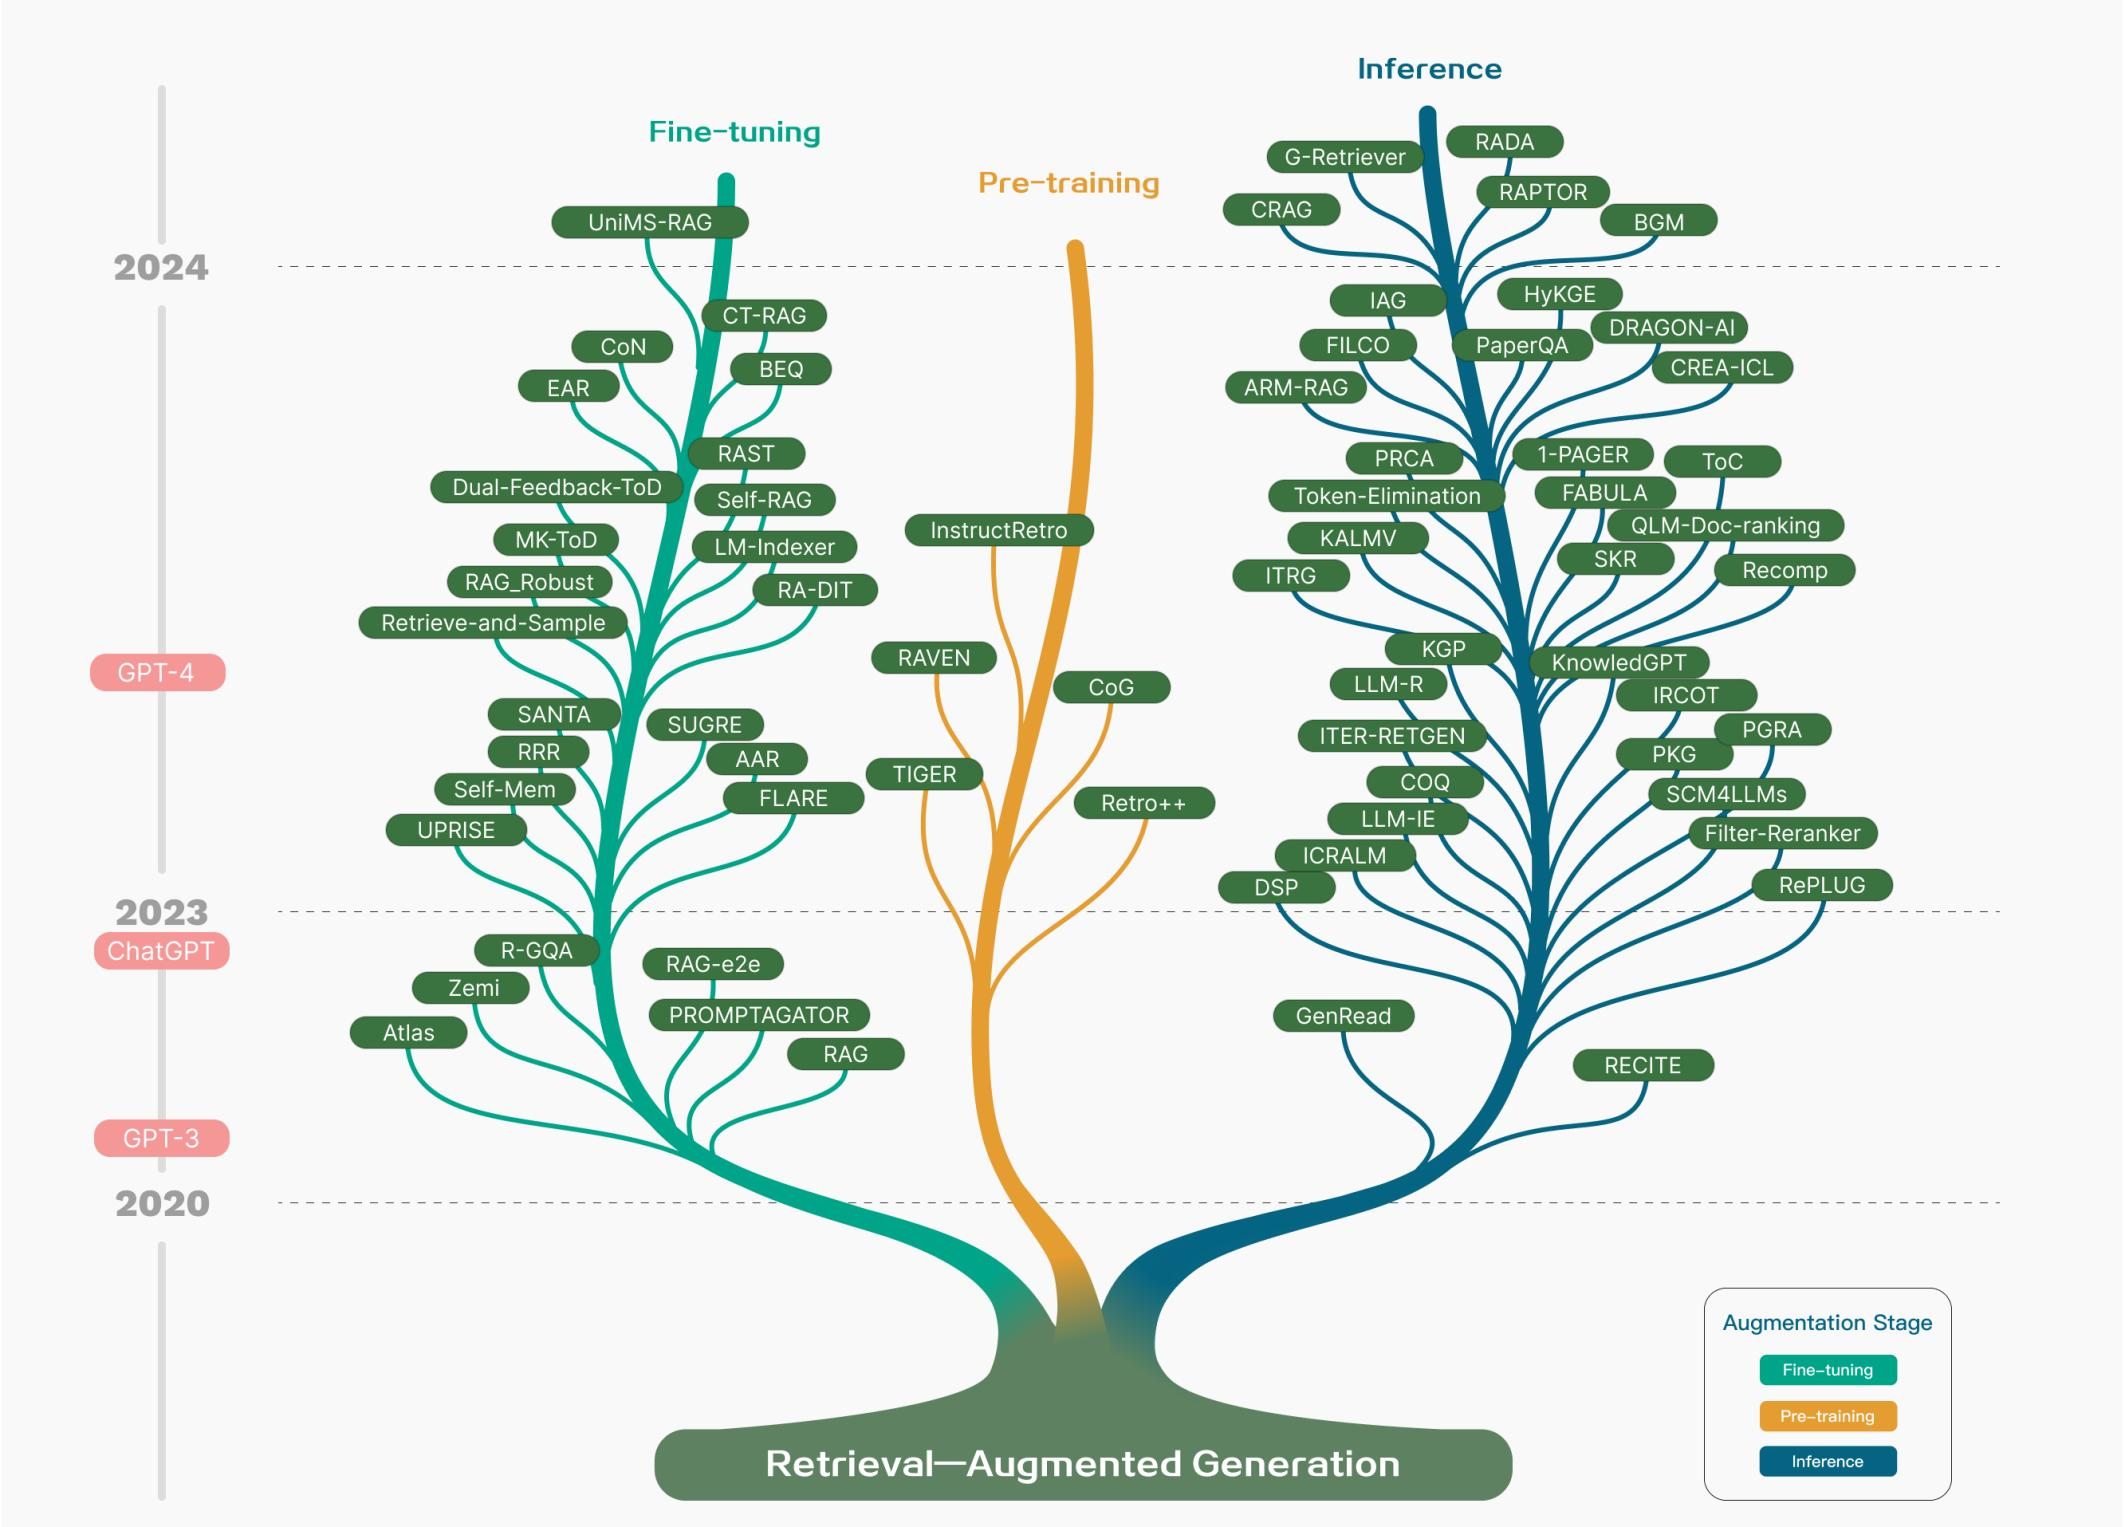

Index : 40 , Caption : Fig. 2. A representative instance of the RAG process applied to question answering. It mainly consists of 3 steps. 1) Indexing. Documents are split into chunks, encoded into vectors, and stored in a vector database. 2) Retrieval. Retrieve the Top k chunks most relevant to the question based on semantic similarity. 3) Generation. Input the original question and the retrieved chunks together into LLM to generate the final answer.


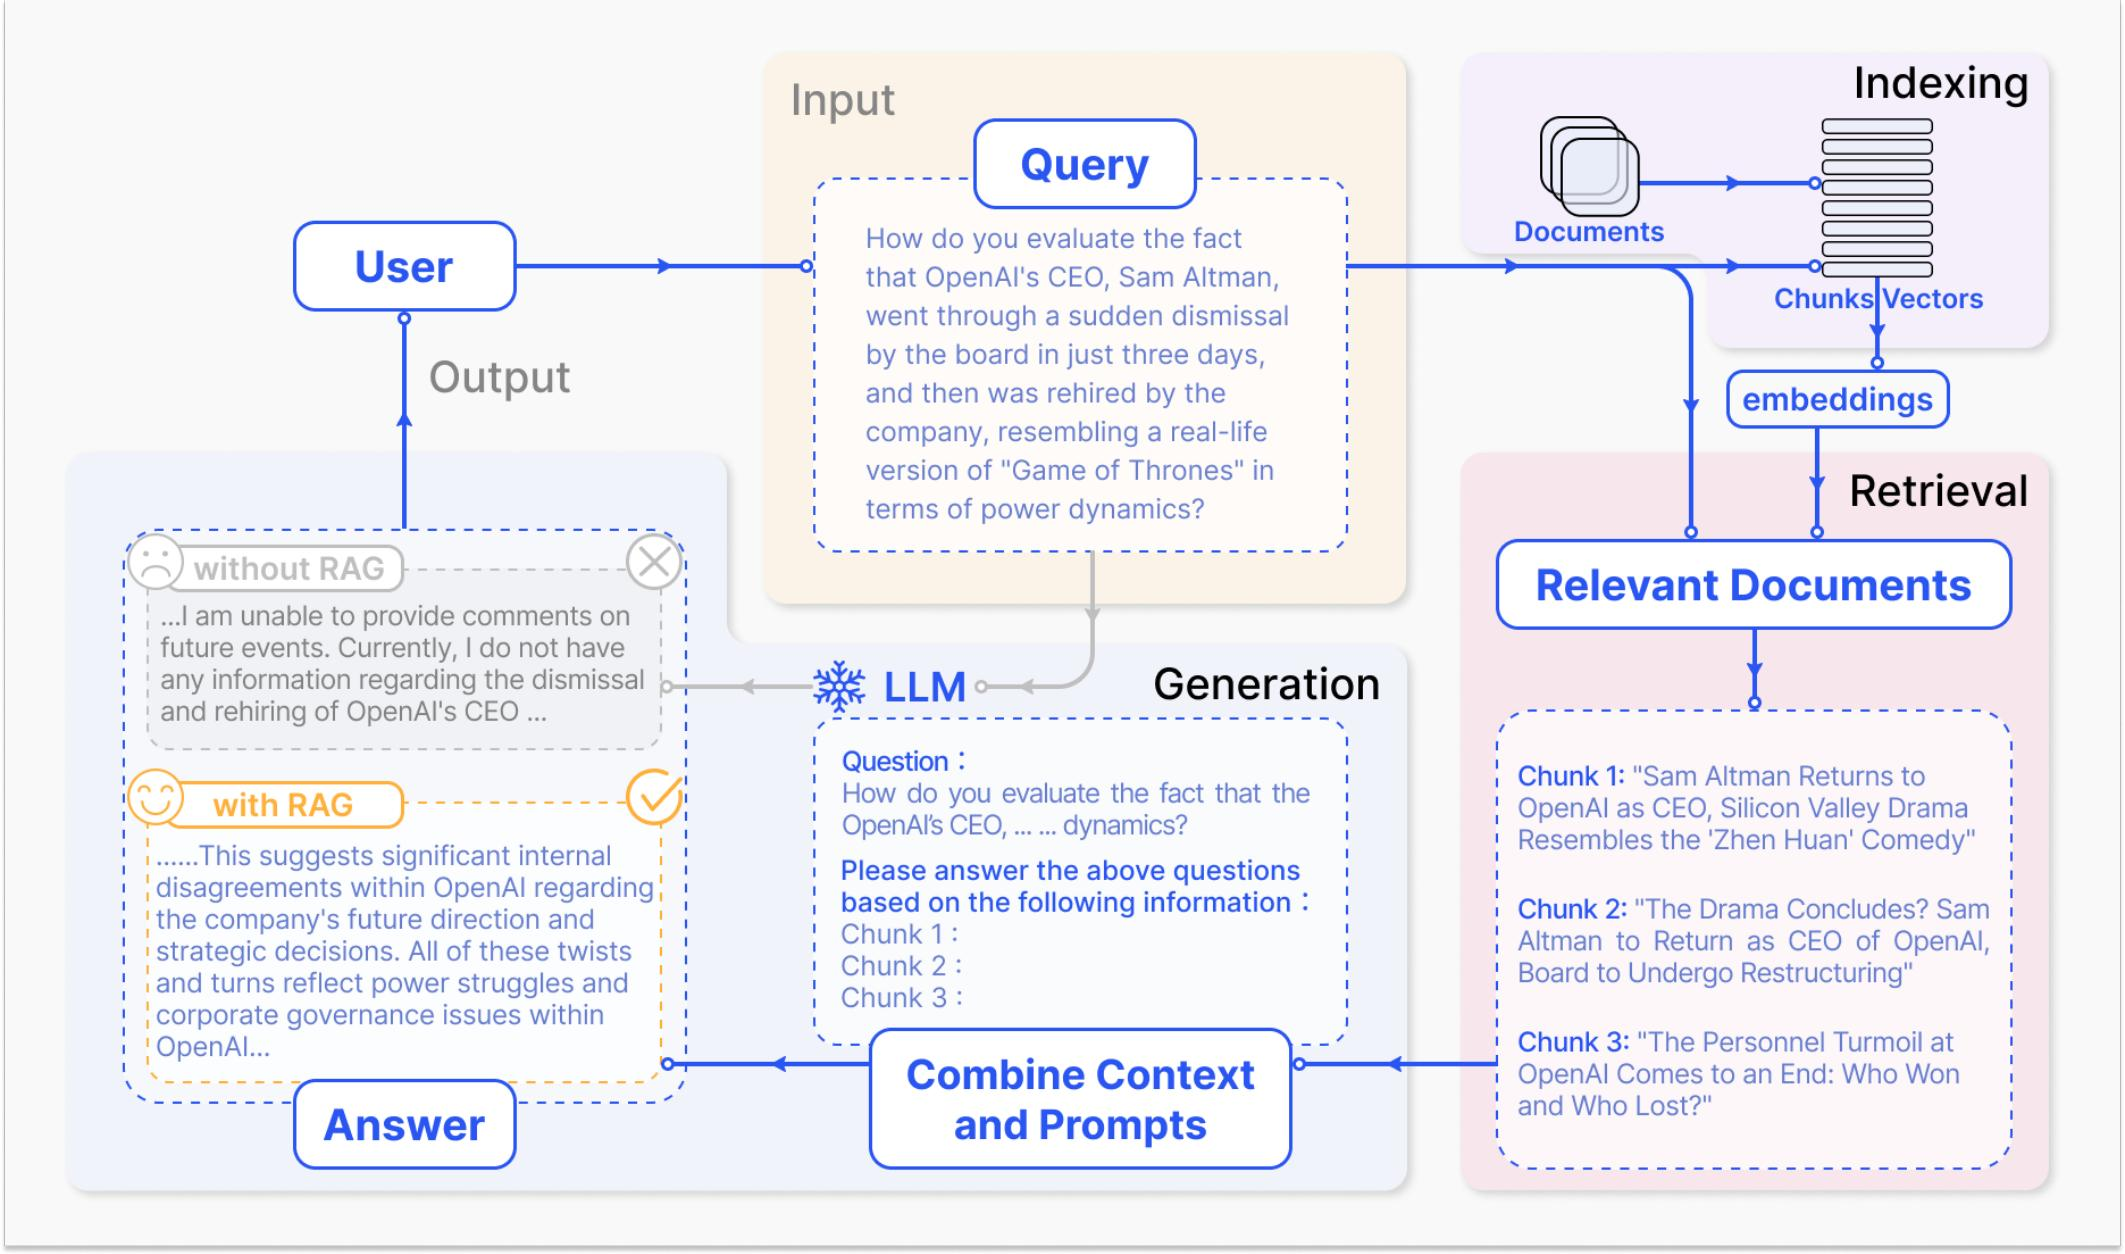

Index : 54 , Caption : Fig. 3. Comparison between the three paradigms of RAG. (Left) Naive RAG mainly consists of three parts: indexing, retrieval and generation. (Middle) Advanced RAG proposes multiple optimization strategies around pre-retrieval and post-retrieval, with a process similar to the Naive RAG, still following a chain-like structure. (Right) Modular RAG inherits and develops from the previous paradigm, showcasing greater flexibility overall. This is evident in the introduction of multiple specific functional modules and the replacement of existing modules. The overall process is not limited to sequential retrieval and generation; it includes methods such as iterative and adaptive retrieval.


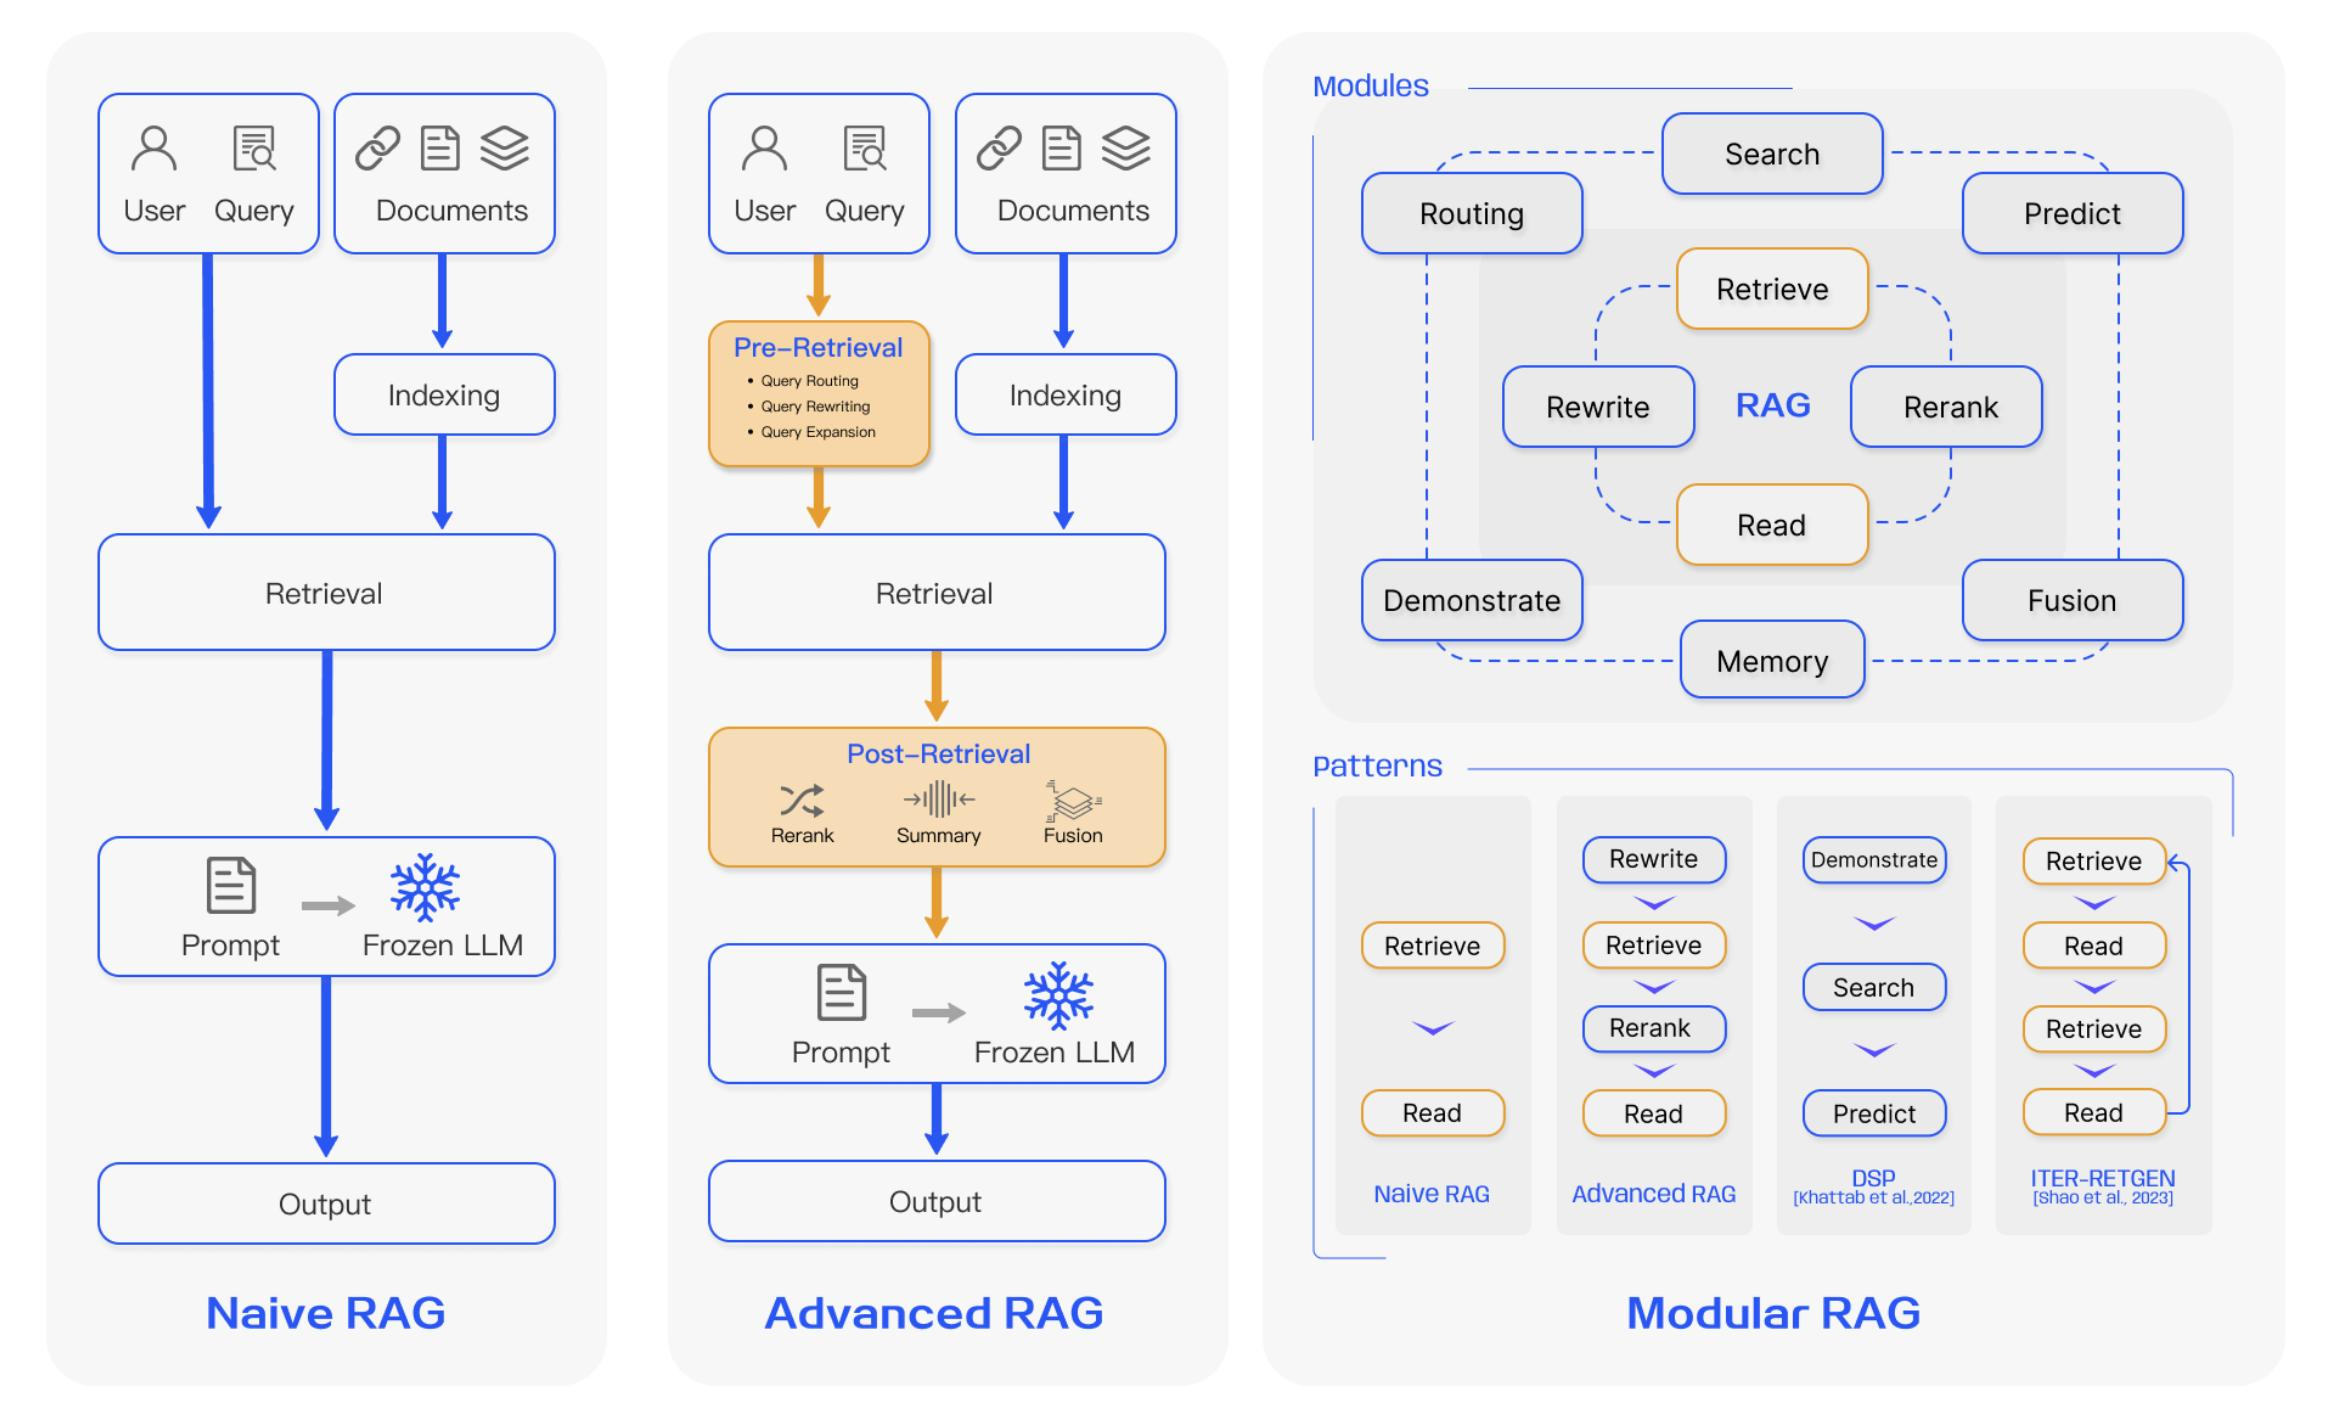

Index : 296 , Caption : Fig. 4. RAG compared with other model optimization methods in the aspects of “External Knowledge Required” and “Model Adaption Required”. Prompt Engineering requires low modifications to the model and external knowledge, focusing on harnessing the capabilities of LLMs themselves. Fine-tuning, on the other hand, involves further training the model. In the early stages of RAG (Naive RAG), there is a low demand for model modifications. As research progresses, Modular RAG has become more integrated with fine-tuning techniques.


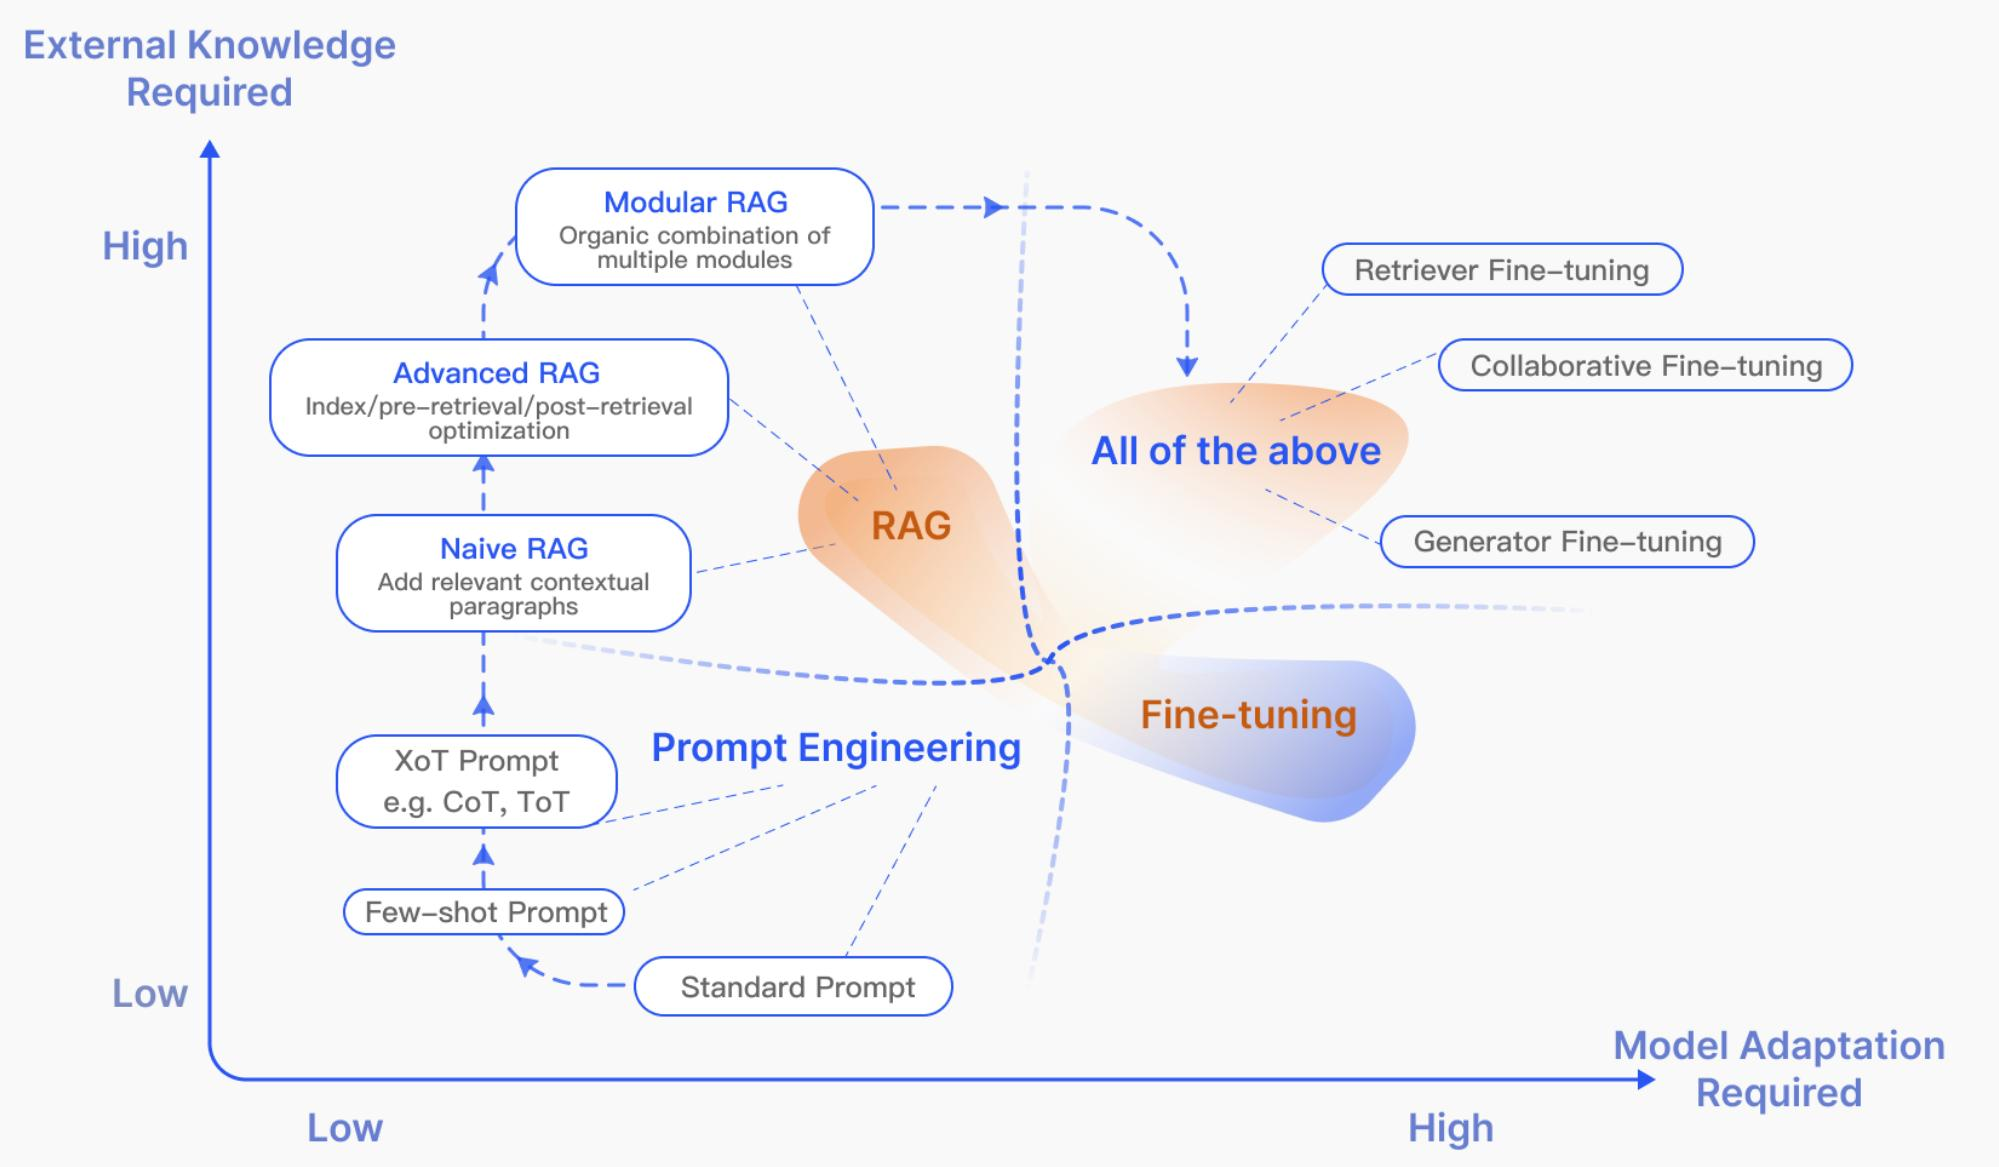

Index : 360 , Caption : Fig. 5. In addition to the most common once retrieval, RAG also includes three types of retrieval augmentation processes. (left) Iterative retrieval involves alternating between retrieval and generation, allowing for richer and more targeted context from the knowledge base at each step. (Middle) Recursive retrieval involves gradually refining the user query and breaking down the problem into sub-problems, then continuously solving complex problems through retrieval and generation. (Right) Adaptive retrieval focuses on enabling the RAG system to autonomously determine whether external knowledge retrieval is necessary and when to stop retrieval and generation, often utilizing LLM-generated special tokens for control.


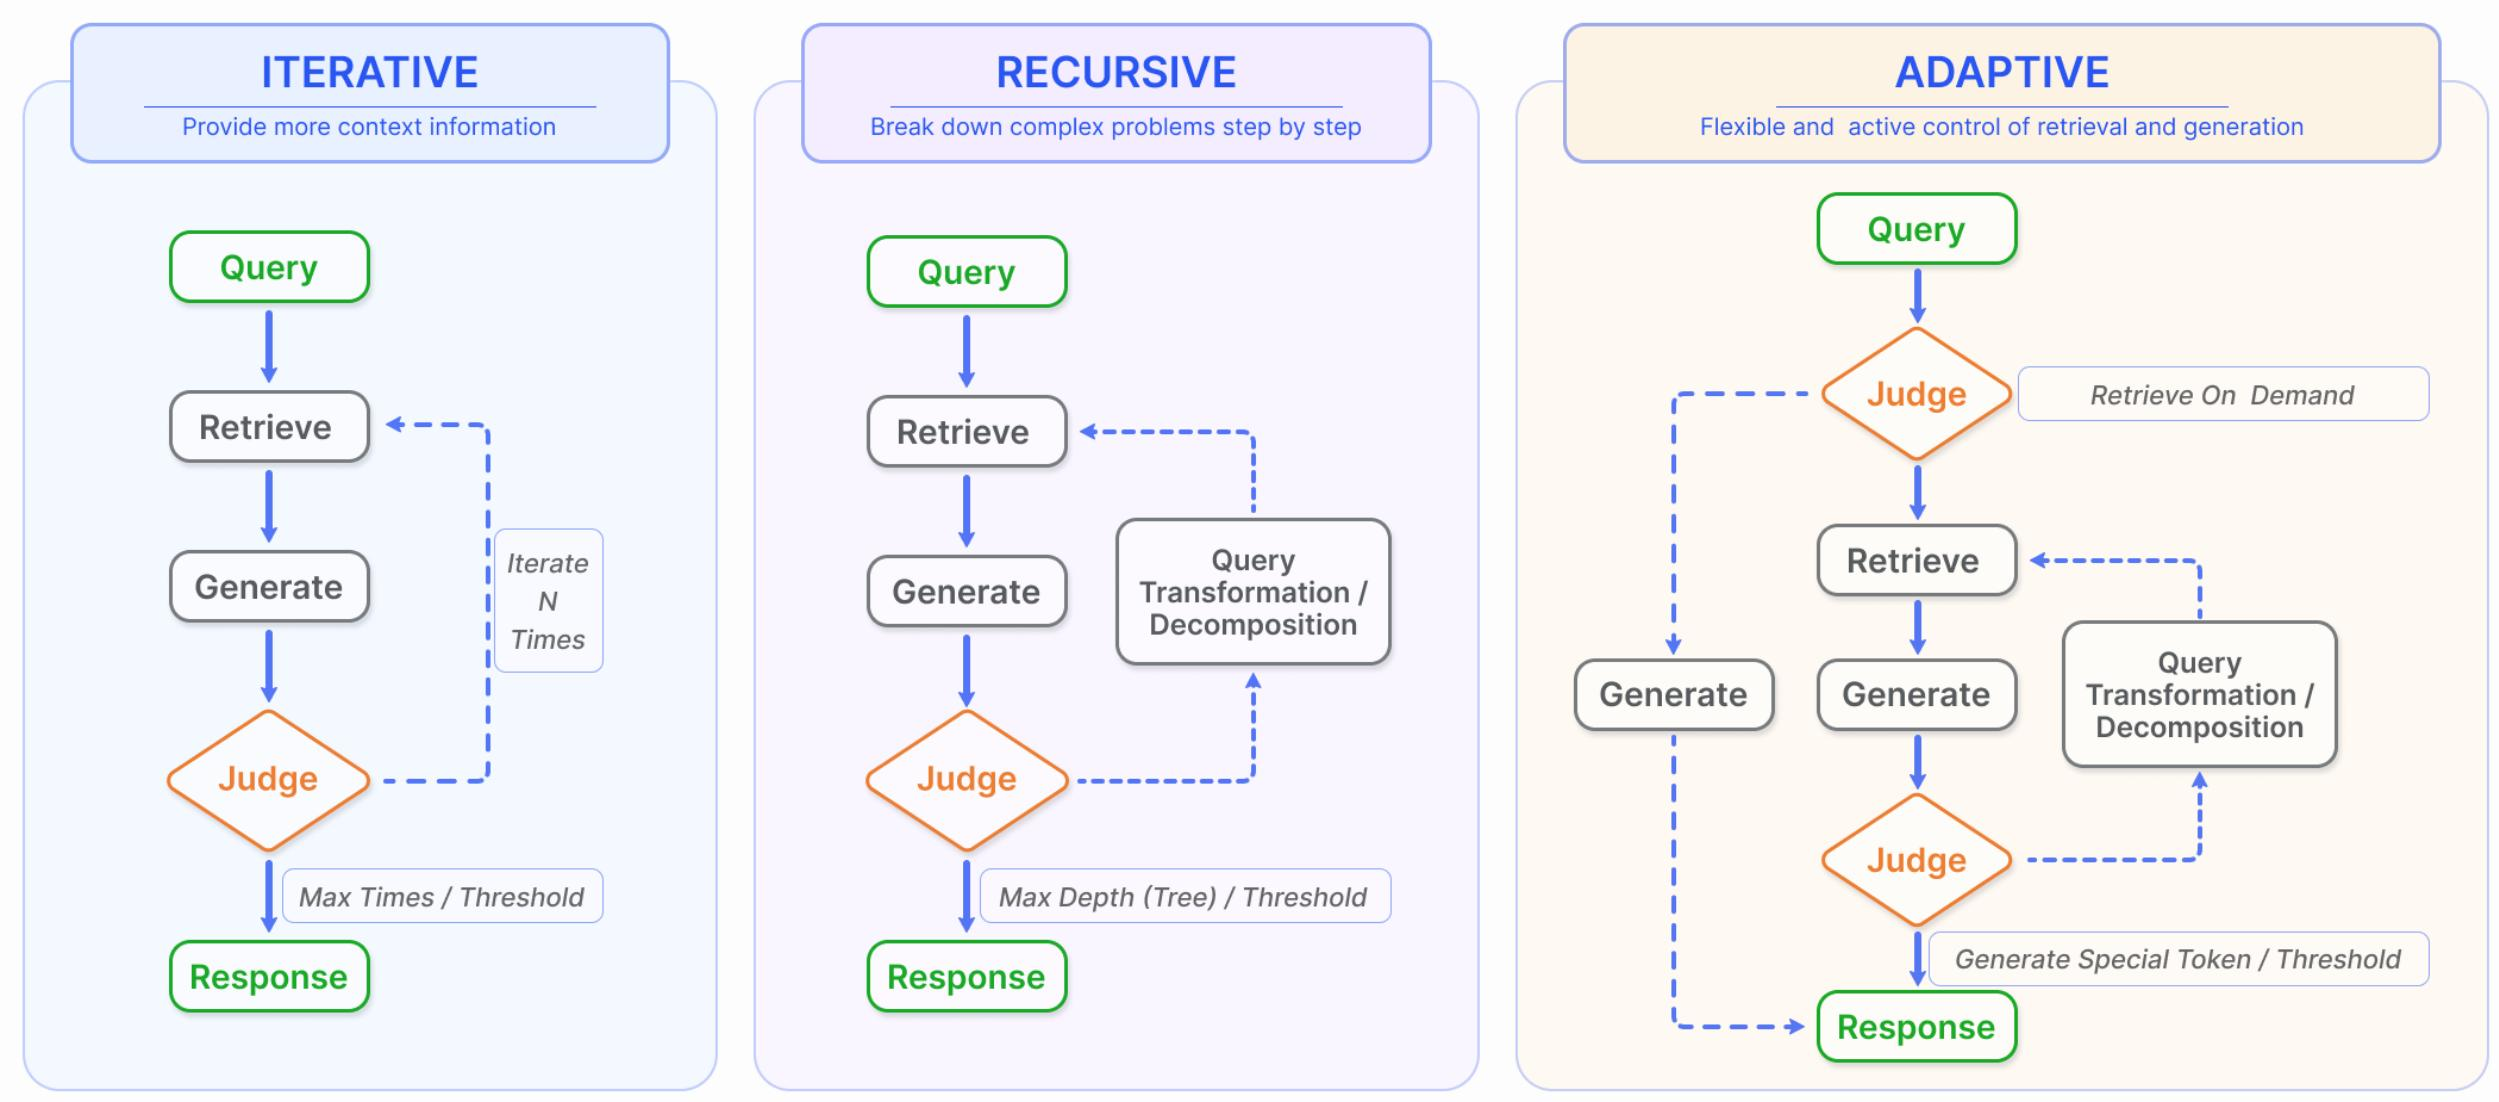

Index : 467 , Caption : No Caption


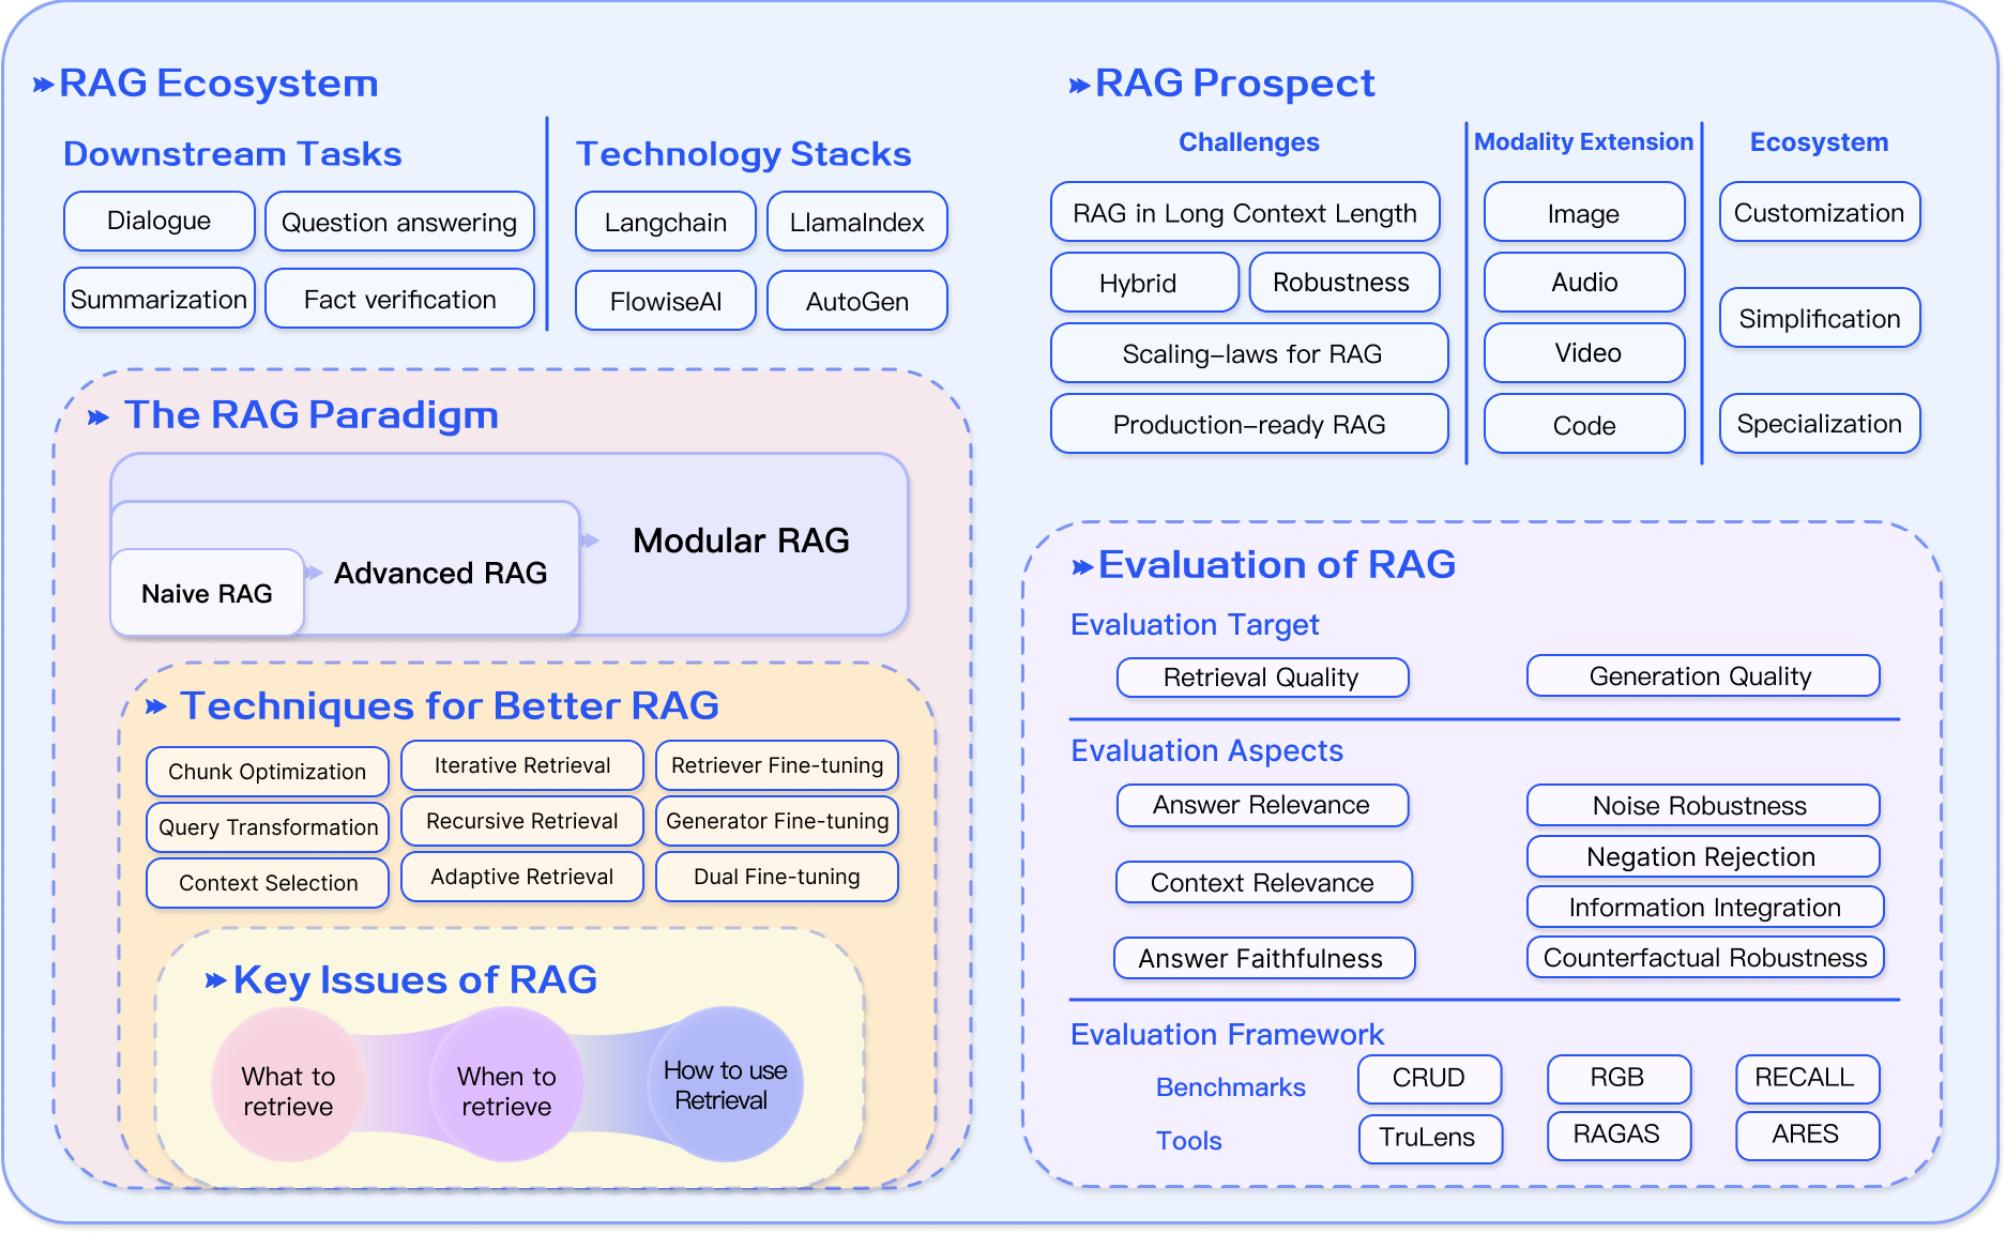

In [19]:
for image_data in all_images:
    print(f"Index : {image_data['index']} , Caption : {image_data['caption']}")
    display_image(image_data['base64_image'])

In [20]:
# Working n Image Captioning
from dotenv import load_dotenv
load_dotenv()
import os 

gemini_api = os.getenv("GEMINI_API_KEY")
if not gemini_api:
    raise ValueError("Cant fnid API")

In [1]:
import google.generativeai as genai 
genai.configure(api_key=gemini_api)

def generate_image_Description(image_data):
    model = genai.GenerativeModel("gemini-2.5-flash")
    image_binary = base64.b64decode(image_data['base64_image'])
    prompt = f"Describe the image in detail. The caption is : {image_data['caption']}. The image text is : {image_data['image_text']}. Please directly return the description without any additional text."

    response = model.generate_content([
        prompt,
        {"mime_type" : "image/png" , "data" : image_binary}
    ])

    return response.text

c:\Users\ADMIN\OneDrive\Desktop\Trial_Gen_ai\Advance_MultiModal RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11836\4189650354.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


NameError: name 'gemini_api' is not defined

In [28]:
generate_image_Description(all_images[0])

'The image displays a "Technology tree of RAG research," visually illustrating the evolution and categorization of Retrieval-Augmented Generation (RAG) techniques over time.\n\n**Overall Structure:**\nThe diagram is presented as a branching tree, originating from a common base labeled "Retrieval—Augmented Generation" at the bottom. This base, a horizontal dark green rounded rectangle, serves as the foundation for the entire field. From this trunk, three main branches ascend, each representing a different "Augmentation Stage" and distinguished by color: Fine-tuning (teal/green), Pre-training (orange), and Inference (dark blue).\n\n**Temporal Axis:**\nA vertical timeline on the left side anchors the research progression. Horizontal dashed lines extend from this timeline into the tree structure, marking specific years and significant LLM milestones:\n*   **2020** (near the bottom, associated with the early stages of RAG).\n*   **GPT-3** (a pink node, positioned slightly above 2020).\n*   

In [32]:
# Working on Tables Parsing...
from unstructured.documents.elements import Table

table_data = []
for idx , element in enumerate(raw_chunks):
    if isinstance(element , Table):
        table_data.append({
            "table_as_html" : element.metadata.text_as_html
        }) 
        

In [33]:
table_data[0]

{'table_as_html': '<table><thead><tr><th></th><th>Retrieval Source</th><th>Retrieval Data Type</th><th>Retrieval Granularity</th></tr></thead><tbody><tr><td></td><td>Wikipedia</td><td>Text</td><td>Phrase</td></tr><tr><td></td><td>Factoid Wiki</td><td>Text</td><td>Proposition</td></tr><tr><td></td><td>Dataset-base</td><td>Text</td><td>Sentence</td></tr><tr><td></td><td>Dataset-base</td><td>Text</td><td>Sentence</td></tr><tr><td></td><td>Dataset-base</td><td>Text</td><td>Sentence</td></tr><tr><td></td><td>Dataset-base</td><td>Text</td><td>Sentence</td></tr><tr><td></td><td>Search Engine, Wikipedia</td><td>Text</td><td>Sentence</td></tr><tr><td></td><td>Wikipedia</td><td>Text</td><td>Sentence</td></tr><tr><td></td><td>Wikipedia</td><td>Text</td><td>Sentence</td></tr><tr><td></td><td>Dataset-base</td><td>Text</td><td>Sentence</td></tr><tr><td></td><td>Synthesized dataset</td><td>Text</td><td>Sentence</td></tr><tr><td></td><td>Dataset-base</td><td>Text</td><td>Sentence Pair</td></tr><tr><td

In [37]:
# Print the table 
from IPython.display import display,HTML

def display_table_as_html(table_html):
    display(HTML(table_html))

display_table_as_html(table_data[1]['table_as_html'])

In [38]:
# Generate table description using LLM
def generate_table_description(table_html):
    model = genai.GenerativeModel("gemini-2.5-flash")
    prompt = (
        "Analyse the following table and provide a detailed description of its contents,"
        "including the structure,key data points and any notable trends or insights."
        f"here is the table in HTML format : {table_html}"
        "Directly analyze the table and provide a detailed description without any additional text."
    )

    response = model.generate_content([prompt])
    return response.text 

In [39]:
generate_table_description(table_data[1]['table_as_html'])

'This table presents a structured overview of various natural language processing (NLP) sub-tasks, the datasets commonly used for evaluating performance on these tasks, and the methods or research papers associated with them.\n\n**1. Structure:**\n\n*   The table is organized into three columns: "Sub Task," "Dataset," and "Method."\n*   The "Sub Task" column serves as the primary categorical grouping. Many rows in this column utilize the `rowspan` attribute to group multiple related datasets and their methods under a single, broader sub-task category (e.g., "Single-hop," "Multi-hop," "Dialog Generation"). This indicates a hierarchical structure where a main task can be addressed by various datasets and methods.\n*   The "Dataset" column lists specific benchmark datasets relevant to the corresponding sub-task.\n*   The "Method" column contains a list of numerical references enclosed in square brackets (e.g., `[26], [30]`). These numbers likely correspond to specific research papers, mod

In [42]:
# generate Table summary using local Ollama 
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOllama(model = "llama3.2:3b" , temperature=0)
proper_prompt = ChatPromptTemplate.from_messages([
    (
        "system", 
        "You are a precise data analysis assistant. Your sole task is to analyze "
        "the provided HTML table and write a detailed text summary of its structure, "
        "key data points, and insights. Do NOT copy, recreate, or output the table "
        "or HTML code back to the user. Provide ONLY the final summary."
    ),
    (
        "human", 
        "Here is the table HTML format:\n\n{table_html}\n\nDirectly analyze the table "
        "above and provide a detailed summary text."
    )
])
chain = proper_prompt | llm 

result = chain.invoke({"table_html" : table_data[1]['table_as_html']})

In [44]:
print(result.content)

The provided HTML table appears to be a comprehensive dataset of various question answering (QA) tasks, including single-hop, multi-hop, and long-form QA tasks. The table categorizes these tasks into different subcategories based on their characteristics.

**Dataset Distribution:**

The dataset consists of 24 distinct datasets, each with its own unique characteristics and features. These datasets are categorized into several groups, including:

1. **Single-Hop QA:** This group includes 8 datasets, such as Natural Qustion (NQ), TriviaQA (TQA), SQuAD, Web Questions (WebQ), PopQA, MS MARCO, HotpotQA, and MuSiQue.
2. **Multi-Hop QA:** This group consists of 6 datasets, including MS MARCO, HotpotQA, 2WikiMultiHopQA, MuSiQue, Long-form QA, and GraphQA.
3. **Long-Form QA:** This category includes 4 datasets: ELI5, NarrativeQA (NQA), ASQA, and QMSum (QM).
4. **Multi-Choice QA:** This group consists of 2 datasets: QUALITY and ARC.
5. **Dialog Generation:** This category includes 3 datasets: Wiz